# Diabetes Data Exploration

In [1]:
# Import libraries
import pandas as pd
import pyreadstat
import matplotlib.pyplot as plt

In [2]:
# Load databset
file_path = "data/Diabetes_DIQ_L.xpt"
df, meta = pyreadstat.read_xport(file_path)

In [3]:
print("Dataset Dimensions:", df.shape)
df.head()

Dataset Dimensions: (11744, 9)


,SEQN,DIQ010,DID040,DIQ160,DIQ180,DIQ050,DID060,DIQ060U,DIQ070
0,130378.0,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN
1,130379.0,2.0,NaN,2.0,1.0,NaN,NaN,NaN,NaN
2,130380.0,1.0,35.0,NaN,NaN,2.0,NaN,NaN,1.0
3,130381.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,130382.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Display Columns of Interest with Descriptions
columns_of_interest = {
    "SEQN": "Respondent sequence number",
    "DIQ010": "Doctor told you have diabetes",
    "DID040": "Age when first told you had diabetes",
    "DIQ160": "Ever told you have prediabetes",
    "DIQ180": "Had blood tested past three years",
    "DIQ050": "Taking insulin now",
    "DID060": "How long taking insulin",
    "DIQ060U": "Unit of measure (month/year)",
    "DIQ070": "Take diabetic pills to lower blood sugar"
}

df = df[list(columns_of_interest.keys())]
df.rename(columns=columns_of_interest, inplace=True)
df.head()

,Respondent sequence number,Doctor told you have diabetes,Age when first told you had diabetes,Ever told you have prediabetes,Had blood tested past three years,Taking insulin now,How long taking insulin,Unit of measure (month/year),Take diabetic pills to lower blood sugar
0,130378.0,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN
1,130379.0,2.0,NaN,2.0,1.0,NaN,NaN,NaN,NaN
2,130380.0,1.0,35.0,NaN,NaN,2.0,NaN,NaN,1.0
3,130381.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,130382.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Frequency Tables
for col in df.columns[1:]:
    print(f"\n=== Frequency for {col} ===")
    print(df[col].value_counts(dropna=False).sort_index())


=== Frequency for Doctor told you have diabetes ===
Doctor told you have diabetes
1.0     1081
2.0    10371
3.0      284
9.0        4
NaN        4
Name: count, dtype: int64

=== Frequency for Age when first told you had diabetes ===
Age when first told you had diabetes
1.0          1
5.0          1
6.0          2
7.0          3
8.0          4
         ...  
78.0         3
79.0         2
80.0         7
999.0       24
NaN      10663
Name: count, Length: 77, dtype: int64

=== Frequency for Ever told you have prediabetes ===
Ever told you have prediabetes
1.0     918
2.0    7089
9.0      15
NaN    3722
Name: count, dtype: int64

=== Frequency for Had blood tested past three years ===
Had blood tested past three years
1.0    3370
2.0    4667
7.0       2
9.0     265
NaN    3440
Name: count, dtype: int64

=== Frequency for Taking insulin now ===
Taking insulin now
1.0      344
2.0      737
NaN    10663
Name: count, dtype: int64

=== Frequency for How long taking insulin ===
How long taking i

In [6]:
# Missing Values Summary
print("\nMissing Values Summary:")
print(df.isna().sum())


Missing Values Summary:
Respondent sequence number                      0
Doctor told you have diabetes                   4
Age when first told you had diabetes        10663
Ever told you have prediabetes               3722
Had blood tested past three years            3440
Taking insulin now                          10663
How long taking insulin                     11401
Unit of measure (month/year)                11412
Take diabetic pills to lower blood sugar     9463
dtype: int64


In [7]:
def mapping_status(data, mapping):
    labels = []
    for key in mapping:
        count_val = data.get(key, 0)
        labels.append(f"{mapping[key]}\n({count_val})")
    return (list(mapping.keys()), labels)

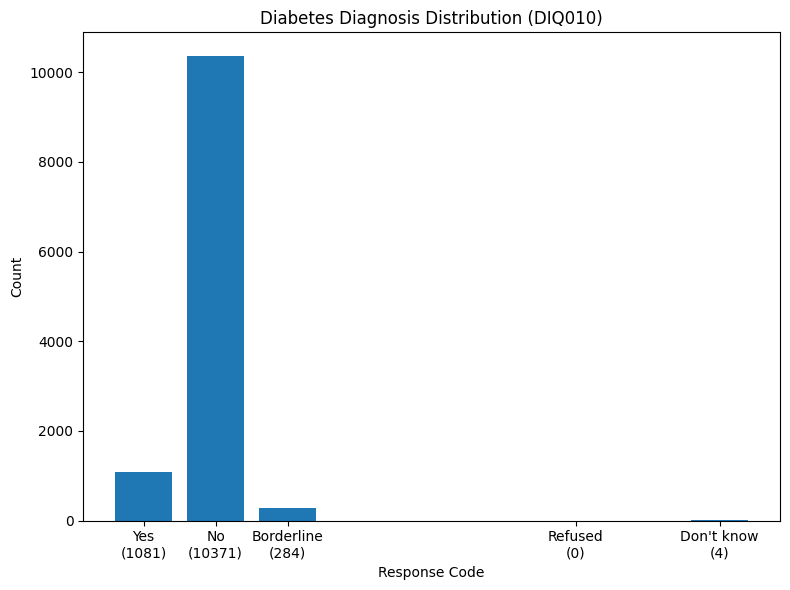

In [8]:
# Visualizing Diabetes Diagnosis Distribution
counts = df['Doctor told you have diabetes'].value_counts().sort_index()
mapping = {1: "Yes", 2: "No", 3: "Borderline", 7: "Refused", 9: "Don't know"}

# Create a bar plot using matplotlib
plt.figure(figsize=(8, 6))
plt.bar(counts.index, counts.values)
plt.title('Diabetes Diagnosis Distribution (DIQ010)')
plt.xlabel('Response Code')
plt.ylabel('Count')

positions, tick_labels = mapping_status(counts, mapping)
plt.xticks(positions, tick_labels, rotation=0)

plt.tight_layout()
plt.savefig("img/iabetes_diagnosis_distribution.png")
plt.show()

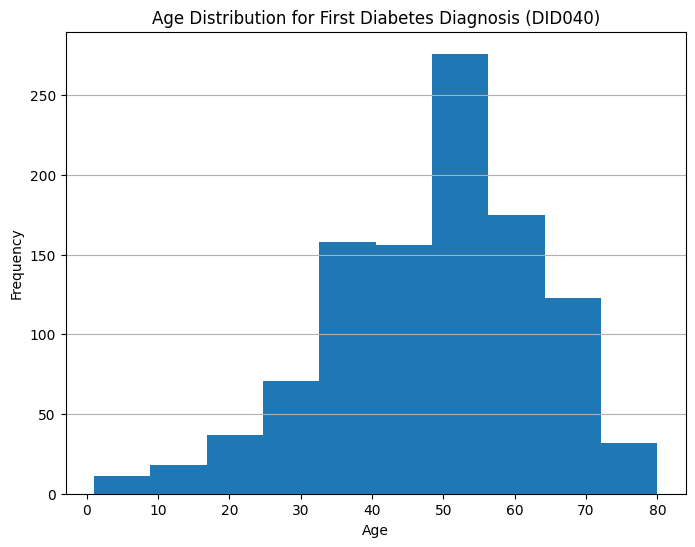

In [9]:
# Graph for Age when first told you had diabetes
age_data = df['Age when first told you had diabetes'].dropna()
age_data_clean = age_data[(age_data >= 1) & (age_data <= 81)] # Ignore codes 666, 777, 999, .

plt.figure(figsize=(8, 6))
plt.hist(age_data_clean)
plt.title('Age Distribution for First Diabetes Diagnosis (DID040)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.savefig("img/age_distribution_diabetes_diagnosis.png")
plt.show()

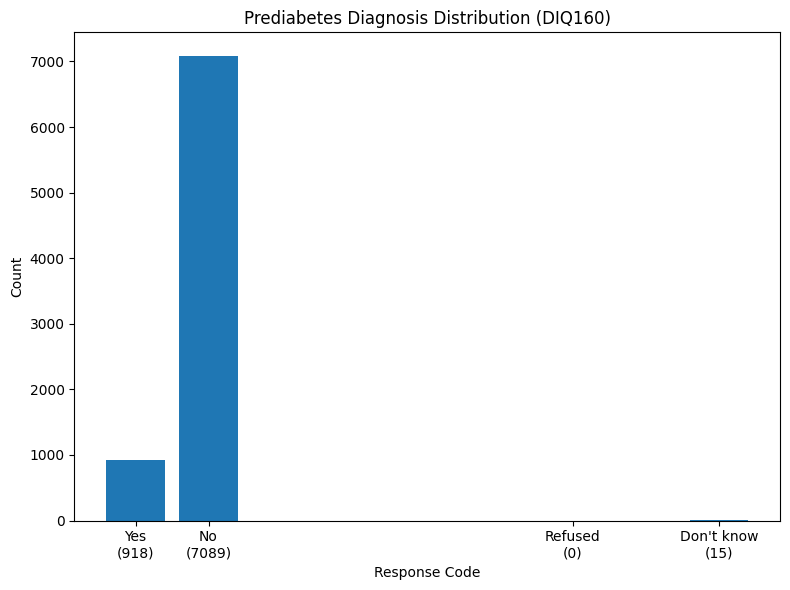

In [10]:
# Graph for Ever told you have prediabetes
counts = df['Ever told you have prediabetes'].value_counts().sort_index()
mapping = {1: "Yes", 2: "No", 7: "Refused", 9: "Don't know"}

plt.figure(figsize=(8, 6))
plt.bar(counts.index, counts.values)
plt.title('Prediabetes Diagnosis Distribution (DIQ160)')
plt.xlabel('Response Code')
plt.ylabel('Count')

positions, tick_labels = mapping_status(counts, mapping)
plt.xticks(positions, tick_labels, rotation=0)

plt.tight_layout()
plt.savefig("img/prediabetes_diagnosis_distribution.png")
plt.show()

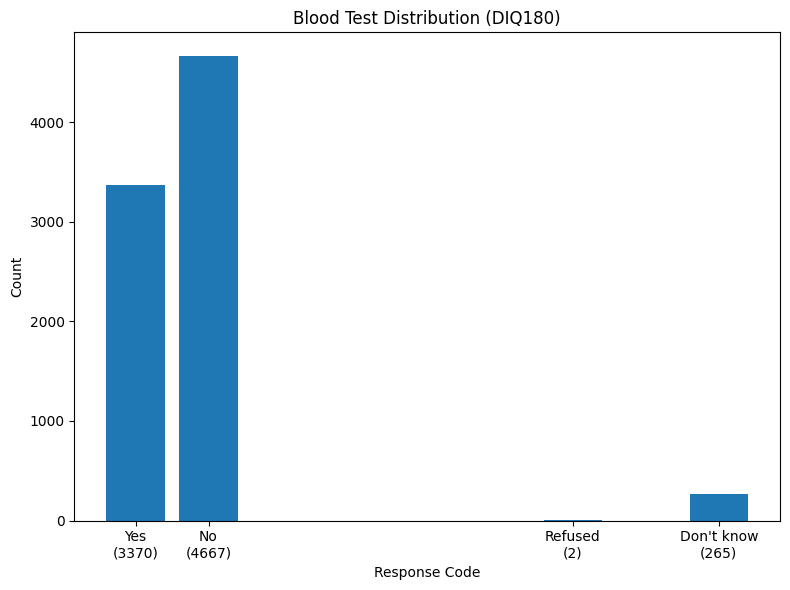

In [11]:
# Graph for Had blood tested past three years
counts = df['Had blood tested past three years'].value_counts().sort_index()
mapping = {1: "Yes", 2: "No", 7: "Refused", 9: "Don't know"}

plt.figure(figsize=(8, 6))
plt.bar(counts.index, counts.values)
plt.title('Blood Test Distribution (DIQ180)')
plt.xlabel('Response Code')
plt.ylabel('Count')

positions, tick_labels = mapping_status(counts, mapping)
plt.xticks(positions, tick_labels, rotation=0)

plt.tight_layout()
plt.savefig("img/blood_test_distribution.png")
plt.show()

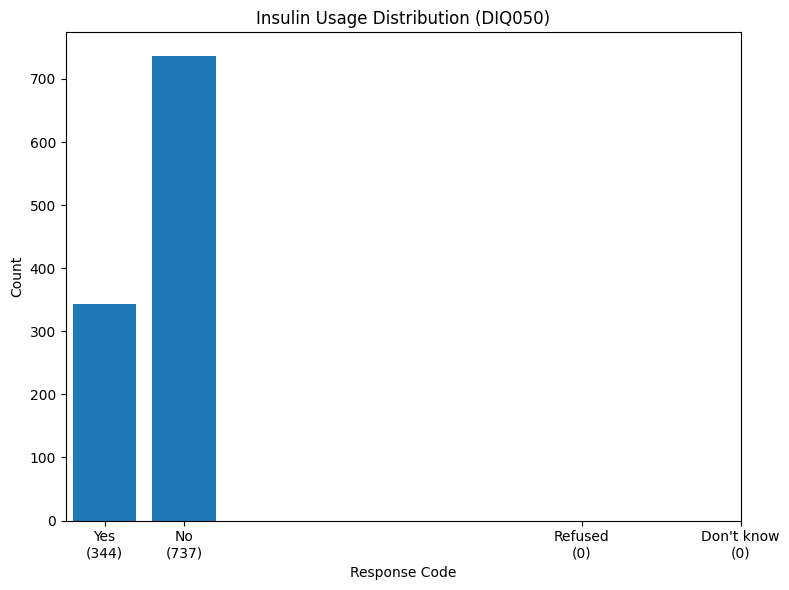

In [12]:
# Graph for Taking insulin now
counts = df['Taking insulin now'].value_counts().sort_index()
mapping = {1: "Yes", 2: "No", 7: "Refused", 9: "Don't know"}

plt.figure(figsize=(8, 6))
plt.bar(counts.index, counts.values)
plt.title('Insulin Usage Distribution (DIQ050)')
plt.xlabel('Response Code')
plt.ylabel('Count')

positions, tick_labels = mapping_status(counts, mapping)
plt.xticks(positions, tick_labels, rotation=0)

plt.tight_layout()
plt.savefig("img/insulin_usage_distribution.png")
plt.show()

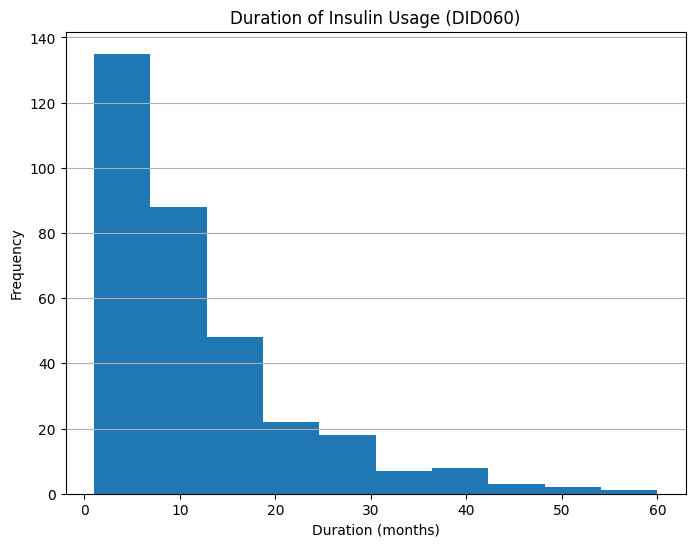

In [13]:
# Graph for How long taking insulin
insulin_duration = df['How long taking insulin'].dropna()
insulin_duration_clean = insulin_duration[(insulin_duration >= 1) & (insulin_duration <= 61)] # Ignore codes 666, 777, 999, .

plt.figure(figsize=(8, 6))
plt.hist(insulin_duration_clean)
plt.title('Duration of Insulin Usage (DID060)')
plt.xlabel('Duration (months)')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.savefig("img/insulin_duration_distribution.png")
plt.show()

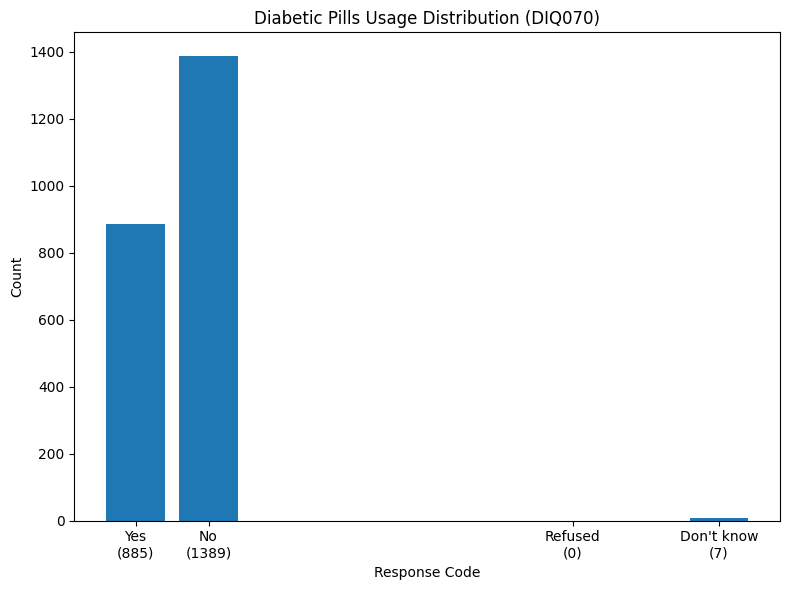

In [14]:
# Graph for Take diabetic pills to lower blood sugar
counts = df['Take diabetic pills to lower blood sugar'].value_counts().sort_index()
mapping = {1: "Yes", 2: "No", 7: "Refused", 9: "Don't know"}

plt.figure(figsize=(8, 6))
plt.bar(counts.index, counts.values)
plt.title('Diabetic Pills Usage Distribution (DIQ070)')
plt.xlabel('Response Code')
plt.ylabel('Count')

positions, tick_labels = mapping_status(counts, mapping)
plt.xticks(positions, tick_labels, rotation=0)

plt.tight_layout()
plt.savefig("img/diabetic_pills_distribution.png")
plt.show()

In [15]:
# Save Cleaned Subset
df.to_csv("cleaned/diabetes_cleaned_subset.csv", index=False)